# SSW2026 Hands On II Group Project Galactic Context Event

Jessica Lu (UC Berkeley), Matthew Penny (LSU), AND Macy Huston (UC Berkeley)

# Microlens or Transit Event in Context
## Galactic Center

Once we have detected a microlensing event or a transiting system, we wish to know everything we can about the lens or the host star. This often requires modeling photometry, estimating distances based on color, luminosity, or parallax, and comparing the proper motions to the surrounding stars. Of course, these are indirect probes of the physical mass, distance, luminosity, and spectral type of the lens/host star. To use the observed quanitities to constrain physical properties, we sometimes need to depend on Galactic models as well.

In this notebook, we will explore what we can learn about the lens or transit host system from the complete Roman GBTDS data set. For this group project, we will perform a similar analysis to that done in the main session but focus on the Galactic Center field rather than the lower bulge. Here, extinction is much higher, as well as stellar density, and we have additional Galactic populations to consider like the Nuclear Stellar Disk (NSD) and Nuclear Star Cluster (NSC).


# Data and import set-up

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord

In [2]:
# Set up access to the data sets
#
# Before running this cell, as described in the Workshop Google Instructions:
# Make shortcut to the shared drive in your top level Google drive:
# Shared drive: https://drive.google.com/drive/folders/1gJhl7zA3lqkiXx3YnAdgU8Q14tUexLlm?usp=sharing_eil&ts=69fcd6a4$0
#
# You will be prompted to Permit this notebook to access your Google Drive files - Click on "Connect to Google Drive"
# You will then be prompted to Choose an account - click on your preferred Google account
# You will then confirm that Google Drive for desktop wants to access your Google Account - select all and scroll to click "Continue"
# You may get another prompt to allow additional access for this to work - scroll to click "Continue"from google.colab import drive

from google.colab import drive
drive.mount('/content/drive')
#this_dir = '/content/drive/Shareddrives/MULab/research/microlens'
#this_dir += '/Roman/2026 Sagan Activity - Galactic Context/'
this_dir = '/content/drive/MyDrive/2026 Sagan Activity - Galactic Context/'

data_dir = this_dir + 'data/'

Mounted at /content/drive


# Data set introduction

## Microlensing events table
This is the table of "detected" microlensing events with their best-fit parameters. Some of the columns and units are listed in the table below.

Column | Description | Units
-------|-------------|------
u0     | Projected closest approach | $\theta_E$
t0     | Time of closest approach | days
t_E    | Einstein crossing time | days
pi_E   | Microlensing parallax | $\theta_E$
theta_E | Einstain radius | mas
mag_base_* | Baseline magnitude of target | AB mag
mag_lens_* | Lens magnitude after deblending | AB mag
mag_source_* | Source magnitude after deblending | AB mag
pm_l_cosb_lens | Lens proper motion in R.A. after deblending | mas/yr
pm_b_lens | Lens proper motion in Dec. after deblending | mas/yr
pm_l_cosb_source | Lens proper motion in R.A. after deblending | mas/yr
pm_b_source | Source proper motion in Dec. after deblending | mas/yr


Take a look at the available events and the columns in the table, and select an event to focus on as your target for the rest of the session.



In [3]:
# Read in the events table
events_table = Table.read(data_dir+'events_gc_table.parquet')

# Limit the number of significant digist for easy display:
for col in events_table.itercols():
    if col.info.dtype.kind == 'f':  # Check if it's a float
        col.info.format = '.5g'    # 3 significant figures

In [4]:
# Display a preview of the events table
events_table

star_id,u0,t0,t_E,pi_E,theta_E,mag_base_f146,f_blend_f146,mag_base_f087,f_blend_f087,mag_base_f213,f_blend_f213,mag_base_f062,mag_base_f106,mag_base_f129,mag_base_f158,mag_base_f184,pm_b_lens,pm_l_cosb_lens,pm_b_source,pm_l_cosb_source,pi_lens,pi_source,mag_lens_f062,mag_lens_f087,mag_lens_f106,mag_lens_f129,mag_lens_f146,mag_lens_f158,mag_lens_f184,mag_lens_f213,mag_source_f062,mag_source_f087,mag_source_f106,mag_source_f129,mag_source_f146,mag_source_f158,mag_source_f184,mag_source_f213
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
64336,-0.65207,-128.06,10.383,0.024716,0.15075,23.813,0.64948,99,nan,21.274,0.63934,99,99,25.368,23.005,21.873,-1.5127,-4.3074,-4.7872,-8.4783,0.12244,0.11871,99,99,99,99,25.115,24.276,23.159,22.59,99,99,99,25.857,24.281,23.498,22.365,21.76
61973,1.3639,-217.01,9.2531,0.083612,0.17818,25.586,0.74685,99,nan,22.769,0.76675,99,99,99,24.703,23.465,nan,nan,0.60131,-4.9189,nan,0.10772,99,99,99,99,99,99,99,25.409,99,99,99,99,25.903,25.023,23.752,23.057
50624,-0.36261,739.69,12.663,0.052165,0.25948,25.065,0.11993,99,nan,22.755,0.1741,99,99,99,24.255,23.258,4.4303,-1.5977,nan,nan,0.13501,nan,99,99,99,99,25.203,24.406,23.437,22.962,99,99,99,99,99,99,25.299,24.653
83472,-0.24528,-721.66,4.0617,0.069763,0.11834,25.281,0.94833,99,nan,22.831,0.94177,99,99,99,24.484,23.401,nan,nan,2.8931,-10.418,nan,0.12318,99,99,99,99,99,99,99,99,99,99,99,99,25.338,24.545,23.46,22.896
55604,-0.414,-850.56,3.2625,0.031364,0.070968,25.08,0.59254,99,nan,22.497,0.528,99,99,99,24.211,23.091,nan,nan,3.312,-9.9224,nan,0.12216,99,99,99,99,99,99,25.642,25.087,99,99,99,99,25.648,24.795,23.719,23.191
172467,-1.009,-894.49,3.9485,0.022105,0.091723,24.877,0.76846,99,nan,22.247,0.71809,99,99,99,24.002,22.851,nan,nan,-2.2738,-9.5743,nan,0.12103,99,99,99,99,99,25.795,24.649,24.033,99,99,99,99,25.163,24.304,23.177,22.607
131899,-0.067384,451.47,7.6583,0.031576,0.069001,23.055,0.8366,99,nan,20.796,0.76604,99,99,24.475,22.341,21.328,nan,nan,1.5726,-7.1805,nan,0.12402,99,99,99,99,99,99,99,25.754,99,99,99,24.656,23.249,22.576,21.599,21.085
85436,-0.41883,334.16,8.5694,0.029164,0.13955,23.708,0.58974,99,nan,21.377,0.55023,99,99,25.105,22.93,21.899,0.43971,-3.7573,4.4196,-8.1777,0.12498,0.12091,99,99,99,99,25.402,24.581,23.554,23.059,99,99,99,25.687,24.281,23.552,22.543,22.025
264428,0.20328,92.428,8.988,0.019907,0.093433,25.875,0.03598,99,nan,23.174,0.039396,99,99,99,24.968,23.795,nan,nan,nan,nan,nan,nan,99,99,99,99,99,25.29,24.116,23.516,99,99,99,99,99,99,99,99


In [10]:
# Select your event to explore for this session
# Good ones to try: 2292274
# Try sorting your table for bright events and/or bright lenses to look for other good options
event_star_id = 2292274
event_table_idx = np.argwhere(events_table['star_id']==event_star_id)

print(events_table[event_table_idx])

star_id     u0      t0   ... mag_source_f158 mag_source_f184 mag_source_f213
------- --------- ------ ... --------------- --------------- ---------------
2292274 -0.029677 638.44 ...          25.822          24.433          23.703


## Stars table
This is the catalog of detected "stars" in the subfield we focus on. These "stars" are often blended combinations of multiple stars, with effective combined proper motions and parallaxes measured. Some of the column names and units are in the table below:

Column | Description | Unit
-------|-------------|-----
star_id | Name of Object | -
l_deg | Galactic Longitude | deg
b_deg | Galactic Latitude  | deg
pm_l_cosb | Proper Motion along R.A. | mas/yr
pm_b | Proper Motion along Dec. |mas/yr
pi | Parallax | mas
mag_* | Photometry | AB mag

You can use the star_id column to find your event in this table. The table will show the blended system properties including the source, lens, and any neighbors within 0.09".

In [6]:
# Read in the stars table
stars_table = Table.read(data_dir+'stars_gc_table.parquet')

# Limit the number of significant digist for easy display:
for col in stars_table.itercols():
    if col.info.dtype.kind == 'f':  # Check if it's a float
        col.info.format = '.5g'    # 3 significant figures

In [7]:
# Print a preview of the table
stars_table

star_id,l_deg,b_deg,pm_l_cosb,pm_b,pi,mag_f062,mag_f087,mag_f106,mag_f129,mag_f158,mag_f146,mag_f184,mag_f213
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,-0.019551,-0.19278,-9.0524,4.073,0.12287,99,99,99,99,99,99,99,25.999
1,-0.028411,-0.19068,-7.9064,-0.35101,0.12095,99,99,99,99,25.927,99,24.801,24.152
2,-0.017956,-0.18994,-5.2388,1.8261,0.12881,99,99,99,99,99,99,99,25.798
3,-0.020652,-0.20901,-8.0297,-3.3498,0.12277,99,99,99,99,24.938,25.837,23.779,23.163
4,-0.016666,-0.20927,-8.0163,-1.7173,0.12053,99,99,99,99,99,99,99,99
5,-0.018353,-0.20605,-2.929,-2.6974,0.12789,99,99,99,99,99,99,25.923,25.325
6,-0.016702,-0.2045,-4.5382,-1.4068,0.12427,99,99,99,25.1,23.214,23.946,22.322,21.879
7,-0.018506,-0.1973,-5.2951,-0.67766,0.11975,99,99,99,99,25.066,25.959,23.926,23.349
8,-0.01579,-0.19279,-7.0127,0.38233,0.1235,99,99,99,99,24.398,25.261,23.315,22.747


In [8]:
stars_table[event_star_id]

star_id,l_deg,b_deg,pm_l_cosb,pm_b,pi,mag_f062,mag_f087,mag_f106,mag_f129,mag_f158,mag_f146,mag_f184,mag_f213
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2292274,0.022635,-0.21419,-6.5048,-2.6673,0.28997,99,24.913,23.397,22.315,21.53,21.909,21.173,21.005


# Color-magnitude diagrams
Let's take a look at the stars in our field and put our target in context with a color-magnitude diagram.

What are the structures you see in the CMD? Why are there two branches?

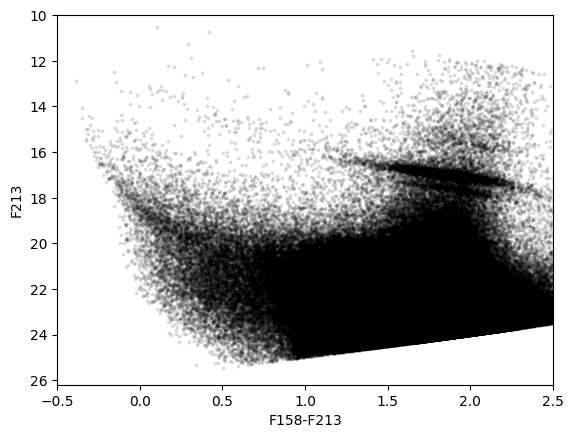

In [9]:
# Plot some color-magnitude diagrams
plt.scatter(stars_table['mag_f158']-stars_table['mag_f213'],
            stars_table['mag_f213'],
            alpha=0.1, s=3, c='black')
plt.ylim(26.2, 10)
# Wider color range than the lower-bulge field: GC extinction (A_Ks ~ 2.3)
# reddens F158-F213 by ~1 mag, producing a second, redder branch.
plt.xlim(-0.5, 2.5)
plt.ylabel('F213'); plt.xlabel('F158-F213');

## Characterizing your lens and source stars
From the microlensing event fit, we have a "source flux fraction." The is the fraction of the total flux of your blended "star" at baseline that is from your source. For these examples, let's assume that any additional blended light comes from the lens. In reality, there are additional factors that may be involved in making this determination, like detected lens-source separation or astrometric microlensing signals.

What can you say about the age of your lens or host star? What population do you think it belongs to?

(-0.5, 2.5)

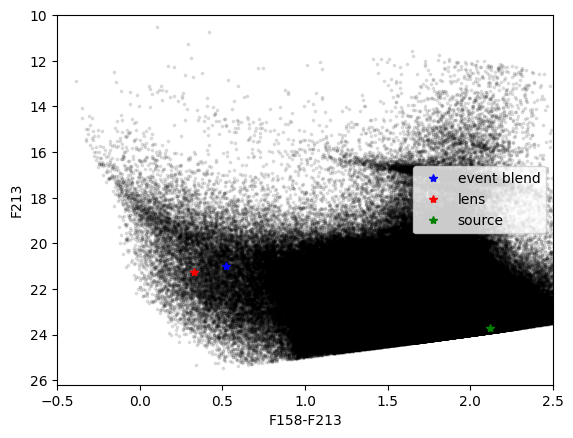

In [11]:
# Plot on your source and lens stars on the CMD
plt.scatter(stars_table['mag_f158']-stars_table['mag_f213'],
            stars_table['mag_f213'],
            c='k', s=3, alpha=0.1)
plt.ylabel('F213'); plt.xlabel('F158-F213');
plt.plot(stars_table['mag_f158'][event_star_id]-stars_table['mag_f213'][event_star_id],
         stars_table['mag_f213'][event_star_id],
         'b*', label='event blend')
plt.plot(events_table['mag_lens_f158'][event_table_idx]-events_table['mag_lens_f213'][event_table_idx],
         events_table['mag_lens_f213'][event_table_idx],
         'r*', label='lens')
plt.plot(events_table['mag_source_f158'][event_table_idx]-events_table['mag_source_f213'][event_table_idx],
         events_table['mag_source_f213'][event_table_idx],
         'g*', label='source')
plt.legend(loc='center right')
plt.ylim(26.2, 10)
plt.xlim(-0.5, 2.5)

# Now, let's put these into context with some simulations
We can use a Galactic model to better understand the stellar populations shown in the CMDs.

## Simulating the Galaxy
We use PopSyCLE to simulate a realistic population of stars in a sample GBTDS subfield. This generates stars from the major Galactic populations: the bulge, disk, and halo. Each population has a distribution throughout the Galaxy, ages, metallicities, etc. The simulation includes a dustmap to apply realistic extinction.

![galaxy_diagram.png](https://drive.google.com/uc?export=view&id=1Bs-3VImwHTl43kjibM1MPul96ZmphE5f)

In this catalog, populations 3-10 are different components of the disk, 1 is the halo, and 0 is the bulge. The halo can generally be ignored in microlensing toward surveys the bulge (not toward the LMC/SMC!). Population 2 in the Nuclear Stellar Disk which contributes negligibly in the lower bulge fields. However, it is important in the GC here!

Knowing which population your star belongs to can give you hints about things like its age, metallicity, and distance. We can compare our planetary host stars to the model catalog stars to try to disentangle some of these stellar properties.

Let's load up our Galactic model catalog.

In [12]:
# Load up the simulation table and print the column names / a few example rows
# Note: we downsampled the simulation catalog by a factor of 1/4 since the field is so dense
# You can downsample more as needed for reasonable plotting code execution times
sim_table = Table.read(data_dir+'sim_pops_gc_table.parquet')
print(sim_table.columns)
sim_table[:10]

<TableColumns names=('obj_id','pop_id','l_deg','b_deg','distance','pm_b','pm_l_cosb','rad_vel','mag_f062','mag_f087','mag_f106','mag_f129','mag_f158','mag_f146','mag_f184','mag_f213','age','zams_mass','mass','systemMass','log_L','log_g','log_Teff','N_companions','type','A_Ks','mag_f062_abs','mag_f087_abs','mag_f106_abs','mag_f129_abs','mag_f158_abs','mag_f146_abs','mag_f184_abs','mag_f213_abs','__index_level_0__')>


obj_id,pop_id,l_deg,b_deg,distance,pm_b,pm_l_cosb,rad_vel,mag_f062,mag_f087,mag_f106,mag_f129,mag_f158,mag_f146,mag_f184,mag_f213,age,zams_mass,mass,systemMass,log_L,log_g,log_Teff,N_companions,type,A_Ks,mag_f062_abs,mag_f087_abs,mag_f106_abs,mag_f129_abs,mag_f158_abs,mag_f146_abs,mag_f184_abs,mag_f213_abs,__index_level_0__
int64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
0,0,-0.027734082538415805,-0.2016355215213347,8.354686441293238,0.9142359195879406,-4.050672407461367,-193.16280442387014,51.10897936679069,38.76087280122766,33.74783204862437,30.102095593146842,27.60142024283835,28.525191121579866,26.377596254104184,25.685995208574425,10.0,0.25462538113611993,0.2546207521869027,0.2546207521869027,-1.966734143553967,5.012372506774756,3.563384143061093,0.0,0,1.9492454466392908,10.354507397209929,9.33922319582882,9.063302191453573,8.885409379415714,8.775959547949608,8.91776568356257,8.844077308732182,8.991105118151884,0
7,0,-0.017851084503092807,-0.20582991746778617,8.064778025064944,-1.0382980250555642,-13.874585759397466,-43.73891145580195,47.5819009388316,37.15622827930105,33.10842013374549,30.241966473709525,28.384678937923873,29.148968087275136,27.537563550910473,26.990991271208145,10.0,0.11720837965532759,0.11720748090100754,0.11720748090100754,-2.8561707194296084,5.19401296327361,3.472609507613043,0.0,0,1.4308675195435714,13.857012291248186,11.75033683836631,11.17986952518989,10.859029010388419,10.75704988520564,10.947328227298142,10.858300179750186,10.927333693339861,7
11,0,-0.017953740840880528,-0.18994029993136755,7.716243936015686,2.104586981776373,-5.259489607204183,-259.2911948695176,48.64426883474666,37.485266153554186,33.0263642369769,29.801160499922375,27.617104374336844,28.452449762124818,26.57661098333983,25.97526064355384,10.0,0.185378138514384,0.18537564882279214,0.18537564882279214,-2.301120706154517,5.0889402812771625,3.534053500131714,0.0,0,1.6913575441793156,11.521414356360953,10.195885769234264,9.847376023976482,9.631215359706086,9.522022267968433,9.678857943265871,9.60254492369492,9.7288716668698,11
15,0,-0.02758280289145887,-0.19219647653742047,8.58795394924355,-3.6387261533385433,-8.240517555027143,173.53288885339202,46.697947143638196,35.608230754217324,31.090257406897052,27.782400986908875,25.46683563544768,26.33043263730072,24.349376165146506,23.779630534356414,10.0,0.5262511798832241,0.5262286201850945,0.5262286201850945,-1.2238752252963507,4.743489575786941,3.602996000205915,0.0,0,1.7698741422632778,8.289547177360559,7.489796731330841,7.273029148348072,7.113902307037583,6.969519769631921,7.123109121390974,7.025116416877337,7.216828265898194,15
20,0,-0.021829610383576892,-0.2002381599580596,8.151591794336023,-0.19998814325350464,-11.905977735319826,150.52954654324995,nan,nan,nan,nan,nan,nan,nan,nan,10.0,1.3512356042759317,0.5412846808660765,0.5412846808660765,nan,nan,nan,0.0,101,1.7744715266864812,nan,nan,nan,nan,nan,nan,nan,nan,20
24,0,-0.015788581611957397,-0.19279225288225127,8.086004509769678,-0.17980894561433466,-9.272242094932185,-162.68787173801485,46.02040981357475,34.87893272245132,30.40981301127146,27.161049963200014,24.889725523319655,25.759159701986714,23.802693957045904,23.254600222057036,10.0,0.6262145685882516,0.6261887028643894,0.6261887028643894,-1.1584338441019972,4.677920460338939,3.584055693684244,0.0,0,1.711936130735137,8.519898908163944,7.331538856198286,7.022822067386381,6.8197128332972135,6.648496088679142,6.831165191644317,6.696119864869377,6.884556790778184,24
28,0,-0.014274243440070222,-0.2072450200072351,8.194956618957077,-4.2631175471717215,-8.05208727513958,17.54665959530089,47.470973060744775,35.789378958821914,31.058446529922186,27.597843612935907,25.1746419402048,26.08621534058027,24.004384583758647,23.40513283887307,10.0,0.618648901308673,0.618

## From intrinsic properties to observable

First, let's check out the properties of the stars in our catalog in a familiar form: an HR diagram. This shows stellar temperatures versus luminosity, key intrinsic properties that describe their brightness and color.

Text(0.5, 0, 'Effective temperature (K)')

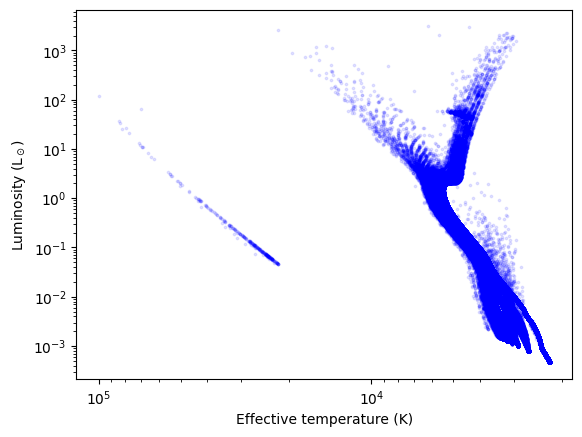

In [13]:
# Plot the HR diagram: temperature versus luminosity.
plt.scatter(10**sim_table['log_Teff'],
            10**sim_table['log_L'],
            c='b', s=3, alpha=0.1)
plt.yscale('log'); plt.xscale('log'); plt.gca().invert_xaxis()
plt.ylabel(r'Luminosity (L$_\odot$)'); plt.xlabel('Effective temperature (K)')

Next, let's move this one step closer to what we'll see with Roman: absolute magnitudes in the Roman filters. First, let's take a look at what the Roman filters (figure from Roman User Documentation / STScI). ![roman_filters_rdox.png](https://drive.google.com/uc?export=view&id=1tlk5PubIluyP-5kTaTdu7ZbmO-9OQ0JE) There are 7 standard-width filters from optical wavelengths through near-infrared (0.5 2.25 microns). The F146 filter, the primary filter for the GBTDS is very wide, covering 1-2 microns.

Let's look at a color-magnitude diagram (CMD), which is similar to the HR diagram, selecting two photometric filters from Roman to use as proxies for luminosity and temperature. Note: we are using absolute magnitudes here, so this is representative of the star's intrinsic properties with no effects from distance or extinction.

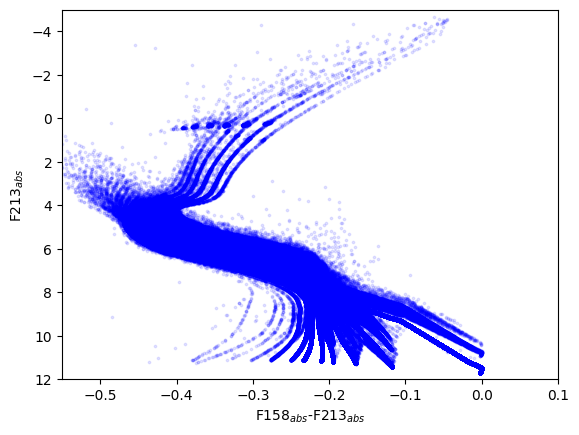

In [14]:
# Plot the absolute CMD in two example Roman filters
plt.scatter(sim_table['mag_f158_abs']-sim_table['mag_f213_abs'],
            sim_table['mag_f213_abs'],
            c='b', s=3, alpha=0.1)
plt.ylim(12,-5); plt.xlim(-0.55,0.1)
plt.ylabel(r'F213$_{abs}$'); plt.xlabel(r'F158$_{abs}$-F213$_{abs}$');

When we convert from absolute magnitudes to apparent, we must account for the impact of distance and extinction. Distance simply makes stars appear more or less dim, moving them up or down on this plot. Dust between us and the star also changes the light we see, blocking some fraction of it from reaching us. Shorter wavelengths are more strongly impacted by this effect than longer, so it causes stars to appear both dimmer (extinction) and redder (reddening).

Let's separate the disk and bulge stellar populations now, since these populations have different ages and distributions in distance (and thus extinction). Our next color-magnitude diagram shows the stars' apparent magnitudes, which allows us to compare it to observational data.

In [15]:
# Separate the bulge and disk populations
sim_table_disk = sim_table[sim_table['pop_id']>=3]
sim_table_nsd = sim_table[sim_table['pop_id']==2]
sim_table_bulge = sim_table[sim_table['pop_id']==0]

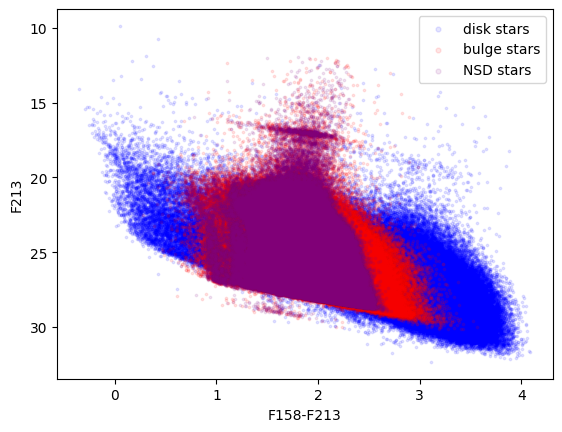

In [16]:
# Make a CMD of simulated stars with color-coding by population
plt.scatter(sim_table_disk['mag_f158']-sim_table_disk['mag_f213'],
            sim_table_disk['mag_f213'],
            c='b', s=3, alpha=0.1,
            label='disk stars')
plt.scatter(sim_table_bulge['mag_f158']-sim_table_bulge['mag_f213'],
            sim_table_bulge['mag_f213'],
            c='r', s=3, alpha=0.1,
            label='bulge stars')
plt.scatter(sim_table_nsd['mag_f158']-sim_table_nsd['mag_f213'],
            sim_table_nsd['mag_f213'],
            c='purple', s=3, alpha=0.1,
            label='NSD stars')
plt.gca().invert_yaxis()
plt.legend(markerscale=2, loc=1)
plt.ylabel('F213'); plt.xlabel('F158-F213');

## Putting our target in context

Next, we will compare this observed and simulated CMDs and determine which population the lens and source likely belong to.

Now what age would you infer for your lens or host star? Does it belong to the disk or the bulge? Can you say anything about metallicity?

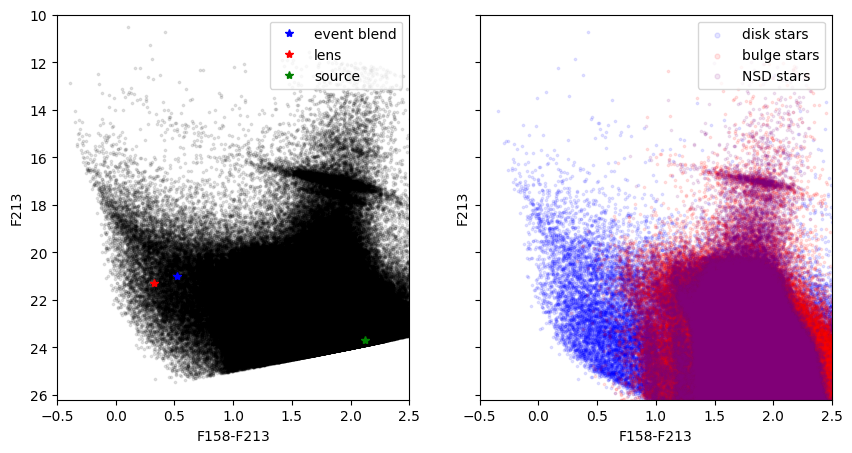

In [17]:
# Compare this CMD to the observed one above. Which populations do your lens and source likely belong to?
def plot_cmd_obs_vs_sim(stars_table, events_table, event_star_id, sim_table):
    """Plot observed and simulated color-magnitude diagrams."""

    # Fetch the indices for the event in each of the tables.
    ss = np.argwhere(stars_table['star_id'] == event_star_id)
    ee = np.argwhere(events_table['star_id'] == event_star_id)

    fig, axs = plt.subplots(1, 2, figsize=(10,5), sharex=True, sharey=True)

    # Plot the observed source, lens, and blend.
    axs[0].scatter(stars_table['mag_f158'] - stars_table['mag_f213'],
                   stars_table['mag_f213'],
                   c='k', s=3, alpha=0.1)
    axs[0].invert_yaxis()
    axs[0].set_ylabel('F213')
    axs[0].set_xlabel('F158-F213')
    axs[0].plot(stars_table['mag_f158'][ss] - stars_table['mag_f213'][ss],
                stars_table['mag_f213'][ss], 'b*', label='event blend')
    axs[0].plot(events_table['mag_lens_f158'][ee] - events_table['mag_lens_f213'][ee],
                events_table['mag_lens_f213'][ee], 'r*', label='lens')
    axs[0].plot(events_table['mag_source_f158'][ee] - events_table['mag_source_f213'][ee],
                events_table['mag_source_f213'][ee], 'g*', label='source')
    axs[0].legend(loc='upper right')

    # Plot the simulated CMD, including the Nuclear Stellar Disk.
    axs[1].scatter(sim_table_disk['mag_f158'] - sim_table_disk['mag_f213'],
                   sim_table_disk['mag_f213'], c='b', s=3, alpha=0.1,
                   label='disk stars')
    axs[1].scatter(sim_table_bulge['mag_f158'] - sim_table_bulge['mag_f213'],
                   sim_table_bulge['mag_f213'], c='r', s=3, alpha=0.1,
                   label='bulge stars')
    axs[1].scatter(sim_table_nsd['mag_f158'] - sim_table_nsd['mag_f213'],
                   sim_table_nsd['mag_f213'], c='purple', s=3, alpha=0.1,
                   label='NSD stars')
    axs[1].invert_yaxis()
    axs[1].legend(markerscale=2, loc='upper right')
    axs[1].set_ylabel('F213')
    axs[1].set_xlabel('F158-F213')
    axs[1].set_ylim(26.2, 10)
    axs[1].set_xlim(-0.5, 2.5)

    return

plot_cmd_obs_vs_sim(stars_table, events_table, event_star_id, sim_table)

In [ ]:
# The CMD comparison above helps identify whether the lens and source are
# more consistent with the disk, bulge, or Nuclear Stellar Disk populations.

The plots above often don't provide enought information to figure out whether the lens is in the disk or the bulge from the CMD alone, but there are additional metrics we can examine.

## Isochrones
An isochrone is a table of current stellar properties for a population of stars with a given age. Each row in the table corresponds to a different initial mass.

Plot some isochrones over your CMD and estimate the mass and radius of your lens star. We will utilize [SPISEA](https://spisea.readthedocs.io/en/latest/) isochrones (pre-computed).

In the SPISEA file names, the first number is the isochrone age in log years. The second number is the extinction in A_Ks (mag). Next is the distance to the stars in parsecs. Next is the metallicity of the stellar population, where 'p' means plus for positive (or zero) metallicity. Finally, we have converted these isochrones from SPISEA's default Vega magnitude system to AB which is standard for Roman.

Our first isochrone here corresponds with a typical bulge/NSD population toward the GC, while the second represents a more nearby disk star with less dust in the foreground and at a younger age.

In [18]:
iso1 = Table.read(this_dir + 'isochrones/iso_10.00_2.30_08000_p0.00_ABmag.fits')
iso2 = Table.read(this_dir + 'isochrones/iso_7.00_0.50_04000_p0.00_ABmag.fits')
iso = [iso1, iso2]

print(iso1.meta)
print(iso1.columns)

{'REDLAW': 'H18b', 'ATMFUNC': 'get_merged_atmosphere', 'EVOMODEL': 'MergedBaraffePisaEkstromParsec', 'EVOMODELVERSION': 'None', 'LOGAGE': 10, 'AKS': 2.3, 'DISTANCE': 8000, 'METAL_IN': 0.0, 'METAL_ACT': 0.0, 'WAVEMIN': 3000, 'WAVEMAX': 52000, 'MAGSYS': 'AB'}
<TableColumns names=('L','Teff','R','mass','logg','isWR','mass_current','phase','m_roman_f062','m_roman_f087','m_roman_f106','m_roman_f129','m_roman_f158','m_roman_f146','m_roman_f184','m_roman_f213')>


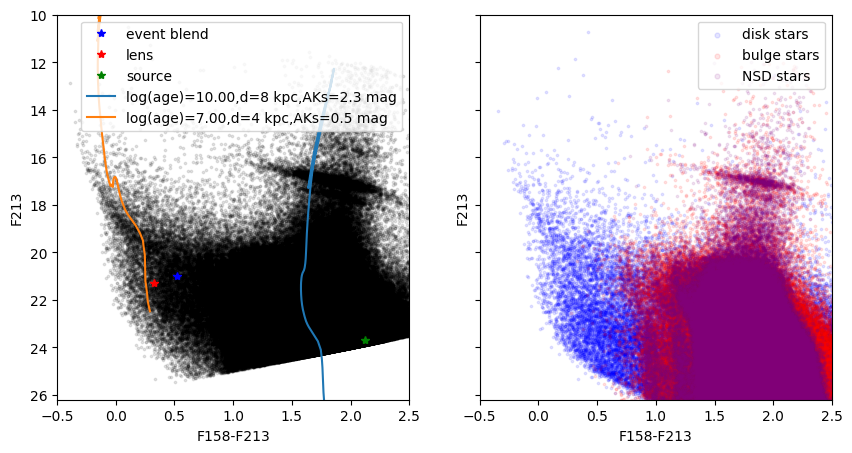

In [19]:
# Plot some isochrones over your CMD and estimate the mass and radius of your lens star
def plot_cmd_obs_vs_sim(stars_table, events_table, event_star_id, sim_table,
                        isochrones=[]):
    """Plot observed and simulated CMDs, with optional isochrones."""

    ss = np.argwhere(stars_table['star_id'] == event_star_id)
    ee = np.argwhere(events_table['star_id'] == event_star_id)

    fig, axs = plt.subplots(1, 2, figsize=(10,5), sharex=True, sharey=True)

    axs[0].scatter(stars_table['mag_f158'] - stars_table['mag_f213'],
                   stars_table['mag_f213'], c='k', s=3, alpha=0.1)
    axs[0].invert_yaxis()
    axs[0].set_ylabel('F213')
    axs[0].set_xlabel('F158-F213')
    axs[0].plot(stars_table['mag_f158'][ss] - stars_table['mag_f213'][ss],
                stars_table['mag_f213'][ss], 'b*', label='event blend')
    axs[0].plot(events_table['mag_lens_f158'][ee] - events_table['mag_lens_f213'][ee],
                events_table['mag_lens_f213'][ee], 'r*', label='lens')
    axs[0].plot(events_table['mag_source_f158'][ee] - events_table['mag_source_f213'][ee],
                events_table['mag_source_f213'][ee], 'g*', label='source')

    axs[1].scatter(sim_table_disk['mag_f158'] - sim_table_disk['mag_f213'],
                   sim_table_disk['mag_f213'], c='b', s=3, alpha=0.1,
                   label='disk stars')
    axs[1].scatter(sim_table_bulge['mag_f158'] - sim_table_bulge['mag_f213'],
                   sim_table_bulge['mag_f213'], c='r', s=3, alpha=0.1,
                   label='bulge stars')
    axs[1].scatter(sim_table_nsd['mag_f158'] - sim_table_nsd['mag_f213'],
                   sim_table_nsd['mag_f213'], c='purple', s=3, alpha=0.1,
                   label='NSD stars')
    axs[1].invert_yaxis()
    axs[1].legend(markerscale=2, loc='upper right')
    axs[1].set_ylabel('F213')
    axs[1].set_xlabel('F158-F213')
    axs[1].set_ylim(26.2, 10)
    axs[1].set_xlim(-0.5, 2.5)

    # Overplot isochrones on the observed CMD.
    for iso_table in isochrones:
        log_age = iso_table.meta['LOGAGE']
        distance = iso_table.meta['DISTANCE'] / 1000.0
        AKs = iso_table.meta['AKS']
        label = f'log(age)={log_age:.2f},d={distance:.0f} kpc,AKs={AKs:.1f} mag'
        axs[0].plot(iso_table['m_roman_f158'] - iso_table['m_roman_f213'],
                    iso_table['m_roman_f213'], ls='-', marker='None', label=label)

    axs[0].legend(loc='upper right')
    return

plot_cmd_obs_vs_sim(stars_table, events_table, event_star_id, sim_table,
                    isochrones=iso)

# Optional: What can we learn from multi-filter photometry?

A Spectral Energy Distribution (SED) is like a low-resolution spectrum of a star, where we have a magnitude measurement in several photometric filters.

Plot an SED for the target. We won't run a full SED fit today, though you could do that for a group project.

From some pre-computed isochrones, we can plot on SEDs of stars with similar F146 mag to roughly estimate potential underlying stellar properties.

Does your star match up well with any SED's from the isochrone? Does one isochrone look like a better fit than the other?

What difficulties can arise in this process, for example if extinction were significantly higher?

For isochrone log(age)=10.00,d=8 kpc,AKs=2.3 mag:
   best-estimate star (based on F146 mag.) = 1.02 Msun, 3.151 Rsun
For isochrone log(age)=7.00,d=4 kpc,AKs=0.5 mag:
   best-estimate star (based on F146 mag.) = 0.18 Msun, 0.565 Rsun


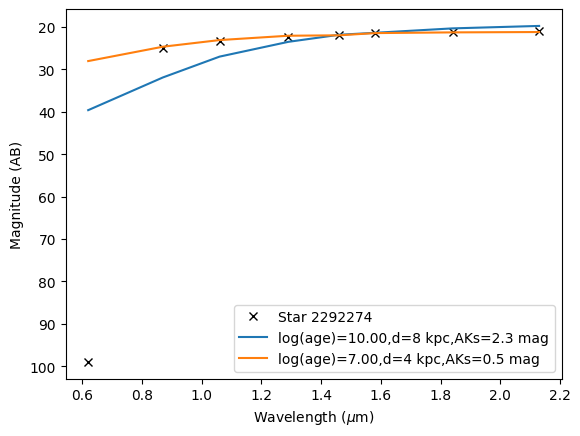

In [20]:
# Plot an SED for the target
star = stars_table[stars_table['star_id'] == event_star_id]
event = events_table[events_table['star_id'] == event_star_id]

def plot_sed(star, event, isochrones=[]):
    """Plot the observed SED and F146-matched isochrone SEDs."""

    # Loop through and get all the magnitude columns.
    mag_cols = []
    filt_name = []
    wavelength = []  # microns

    for col in star.columns:
        if col.startswith('mag_'):
            mag_cols.append(col)
            filt = col.split('_')[-1].upper()
            filt_name.append(filt)
            wavelength.append(float(filt[1:]) / 100.0)

    wavelength = np.array(wavelength)
    filt_name = np.array(filt_name)
    phot = np.array([star[col][0] for col in mag_cols], dtype=float)

    sdx = np.argsort(wavelength)
    wavelength = wavelength[sdx]
    filt_name = filt_name[sdx]
    phot = phot[sdx]
    mag_cols = list(np.array(mag_cols)[sdx])

    plt.figure()
    plt.plot(wavelength, phot, 'kx', label=f'Star {star["star_id"][0]}')

    # Find the nearest isochrone star in F146 magnitude and plot its SED.
    if isochrones:
        iso_mag_cols = [col.replace('mag_', 'm_roman_') for col in mag_cols]

        for iso_table in isochrones:
            mag_obs = star['mag_f146']
            mag_iso = iso_table['m_roman_f146']
            idx = np.argmin(np.abs(mag_obs - mag_iso))
            iso_phot = np.array([iso_table[col][idx] for col in iso_mag_cols], dtype=float)

            log_age = iso_table.meta['LOGAGE']
            distance = iso_table.meta['DISTANCE'] / 1000.0
            AKs = iso_table.meta['AKS']
            label = f'log(age)={log_age:.2f},d={distance:.0f} kpc,AKs={AKs:.1f} mag'
            print(f'For isochrone {label}:')
            print(f"   best-estimate star (based on F146 mag.) = {iso_table['mass_current'][idx]:.2f} Msun, {iso_table['R'][idx]/696000000:.3f} Rsun")
            plt.plot(wavelength, iso_phot, ls='-', marker='None', label=label)

    plt.gca().invert_yaxis()
    plt.legend(loc='lower right')
    plt.xlabel(r'Wavelength ($\mu$m)')
    plt.ylabel('Magnitude (AB)')
    return

plot_sed(star, event, isochrones=iso)

# Kinematics

Next, let's examine the kinematics of the target in context.
Plot the proper motions of the simulation catalog stars by population.
Then, add your lens and source to the plot and see how the fit into the populations.

Note that the reported proper motions from the stars table might be blended in cases where the "star" is actually a binary or where neighbor stars are within the beam. In the events table, the proper motions between the source and lens can be decomposed based on the blending factor measured from the microlensing light curve.

In the case of a lumious source and lens, the observed proper motion is given by

$\vec{\mu}_{blended} = \frac{f_S \vec{\mu}_S + f_L \vec{\mu}_L}{f_S + f_L}$

$\vec{\mu}_{blended} = b_{sff} \vec{\mu}_S + (1 - b_{sff}) \vec{\mu}_L$

Tip if you're low on time: you can use the proper motions and parallaxes provided in the events table.

Optional if you have extra time: compare your blend ratio-derived values to those provided in the table. What happens if you have unrelated neighbor stars in your blend?

Note: deblended source proper motion is NaN for this event; source marker not shown.


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


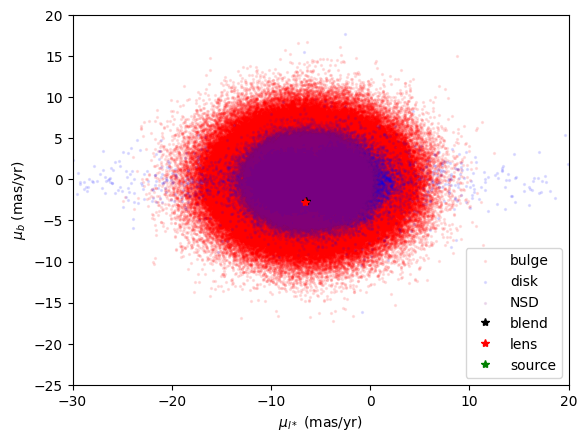

In [21]:
# Plot proper motions in the l and b directions for the simulated populations.
plt.scatter(sim_table_bulge['pm_l_cosb'], sim_table_bulge['pm_b'],
            c='r', s=2, alpha=0.1, label='bulge')
plt.scatter(sim_table_disk['pm_l_cosb'], sim_table_disk['pm_b'],
            c='b', s=2, alpha=0.1, label='disk')
plt.scatter(sim_table_nsd['pm_l_cosb'], sim_table_nsd['pm_b'],
            c='purple', s=2, alpha=0.1, label='NSD')
plt.plot(stars_table['pm_l_cosb'][event_star_id], stars_table['pm_b'][event_star_id],
         'k*', label='blend')
plt.plot(events_table['pm_l_cosb_lens'][event_table_idx],
         events_table['pm_b_lens'][event_table_idx], 'r*', label='lens')
plt.plot(events_table['pm_l_cosb_source'][event_table_idx],
         events_table['pm_b_source'][event_table_idx], 'g*', label='source')
plt.legend()
plt.ylim(-25,20)
plt.xlim(-30,20)
plt.xlabel(r'$\mu_{l*}$ (mas/yr)')
plt.ylabel(r'$\mu_b$ (mas/yr)')

# Warn if the deblended lens/source proper motions are missing for this event,
# in which case only the blend marker appears on the plot.
if not np.all(np.isfinite(events_table['pm_l_cosb_lens'][event_table_idx])):
    print('Note: deblended lens proper motion is NaN for this event; lens marker not shown.')
if not np.all(np.isfinite(events_table['pm_l_cosb_source'][event_table_idx])):
    print('Note: deblended source proper motion is NaN for this event; source marker not shown.')

# Let's take a look at parallaxes

Although lens-source separation can give us the individual proper motions of the source and lens, it will be more difficult to get reliable individual parallaxes. Luckily, we have both the blended parallax from the star catalog and the relative lens-source parallax from the microlensing event, so we can disentangle them if we have a measurement of the Einstein ring radius $\theta_E$.

Much like the proper motions, blended parallax is the flux-weighted mean of the lens and source parallax.
The relative parallax is the difference between the lens and source parallax, which is the microlensing parallax times the Einstein ring radius ($\pi_{rel} = \pi_E \times \theta_E$).
Use these plux your source flux fraction to calculate the individual lens and source parallaxes.

In [22]:
# Calculate the lens and source parallax
flux_lens = 10**(-0.4*events_table['mag_lens_f146'][event_table_idx])
flux_source = 10**(-0.4*events_table['mag_source_f146'][event_table_idx])
pi_rel = events_table['pi_E'][event_table_idx] * events_table['theta_E'][event_table_idx]
pi_blend = stars_table['pi'][event_star_id]
pi_source = (pi_blend*(flux_lens + flux_source) - flux_lens*pi_rel)/(flux_lens+flux_source)
pi_lens = pi_rel + pi_source
print(pi_source, pi_lens)

mag_lens_f146
-------------
      0.11235   pi_E 
-------
0.28997


Can proper motion and parallax also help clarify which populations the stars belong to?

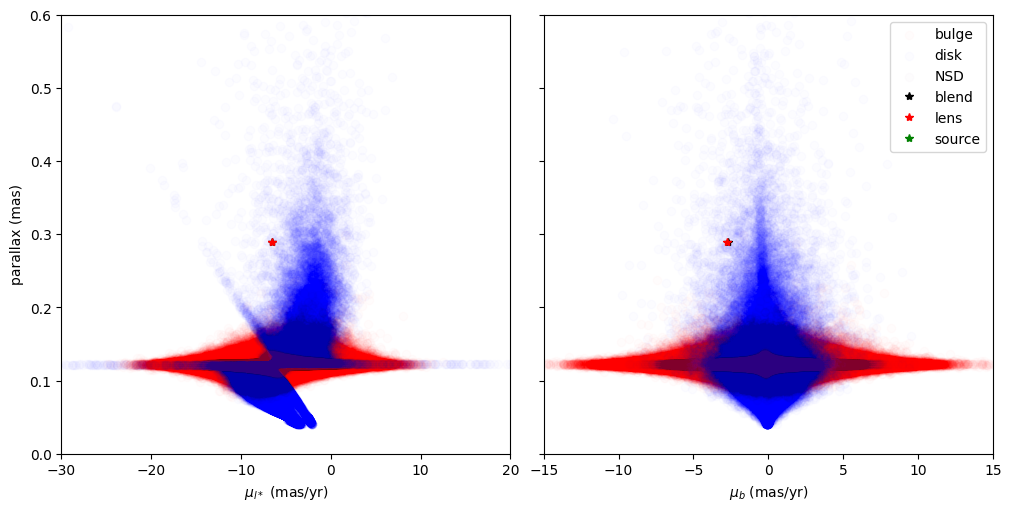

In [23]:
# Plot proper motion versus parallax for the simulation populations
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,5), layout='constrained')
ax[0].scatter(sim_table_bulge['pm_l_cosb'], 1/sim_table_bulge['distance'], c='r', alpha=0.01)
ax[1].scatter(sim_table_bulge['pm_b'], 1/sim_table_bulge['distance'], c='r', alpha=0.01, label='bulge')
ax[0].scatter(sim_table_disk['pm_l_cosb'], 1/sim_table_disk['distance'], c='b', alpha=0.01)
ax[1].scatter(sim_table_disk['pm_b'], 1/sim_table_disk['distance'], c='b', alpha=0.01, label='disk')
ax[0].scatter(sim_table_nsd['pm_l_cosb'], 1/sim_table_nsd['distance'], c='purple', alpha=0.01)
ax[1].scatter(sim_table_nsd['pm_b'], 1/sim_table_nsd['distance'], c='purple', alpha=0.01, label='NSD')

ax[0].plot(stars_table['pm_l_cosb'][event_star_id], pi_blend,'k*', label='blend')
ax[0].plot(events_table['pm_l_cosb_lens'][event_table_idx], pi_lens,'r*', label='lens')
ax[0].plot(events_table['pm_l_cosb_source'][event_table_idx], pi_source,'g*', label='source')
ax[1].plot(stars_table['pm_b'][event_star_id], pi_blend,'k*', label='blend')
ax[1].plot(events_table['pm_b_lens'][event_table_idx], pi_lens,'r*', label='lens')
ax[1].plot(events_table['pm_b_source'][event_table_idx], pi_source,'g*', label='source')

ax[1].legend(loc=1)
ax[0].set_ylim(0,0.6)
ax[0].set_ylabel('parallax (mas)')
ax[0].set_xlabel(r'$\mu_{l*}$ (mas/yr)'); ax[1].set_xlabel(r'$\mu_b$ (mas/yr)')
ax[0].set_xlim(-30,20); ax[1].set_xlim(-15,15);

How about magnitude and parallax?



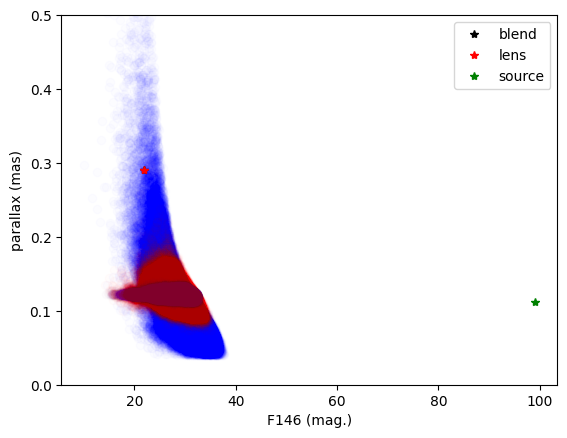

In [24]:
# Plot parallax versus magnitude
plt.scatter(sim_table_disk['mag_f146'], 1/sim_table_disk['distance'], c='b', alpha=0.01)
plt.scatter(sim_table_bulge['mag_f146'], 1/sim_table_bulge['distance'], c='r', alpha=0.01)
plt.scatter(sim_table_nsd['mag_f146'], 1/sim_table_nsd['distance'], c='purple', alpha=0.01)

plt.plot(stars_table['mag_f146'][event_star_id], pi_blend,'k*', label='blend')
plt.plot(events_table['mag_lens_f146'][event_table_idx], pi_lens,'r*', label='lens')
plt.plot(events_table['mag_source_f146'][event_table_idx], pi_source,'g*', label='source')

plt.xlabel('F146 (mag.)'); plt.ylabel('parallax (mas)')
plt.ylim(0,0.5)
plt.legend()

#Star and Planet Masses / Radii

For a microlensing event, we can definitively measure the lens mass if we have the Einstein radius $\theta_{\rm E}$ via astrometric microlensing, lens-source separation, or finite source effects.

It can be derived as $\theta_{\rm E} = \mu_{\rm rel}*t_{\rm E}$ (make sure to check units). If we can measure $\pi_{\rm E}$ from our light curve and/or astrometry, we can then determine the mass of the lens.

$M_{\rm lens}$ = $\theta_{\rm E}$/($\pi_{\rm E} \times$ 8.144 mas/Msun)


In [25]:
# Calculate theta_E
# Some events (including this target) do not have finite deblended lens/source
# proper motions. In that case, use the measured theta_E from the event fit.
t_E = events_table[event_table_idx]['t_E']
mu_rel_pm = np.hypot(
    events_table[event_table_idx]['pm_b_lens'] - events_table[event_table_idx]['pm_b_source'],
    events_table[event_table_idx]['pm_l_cosb_lens'] - events_table[event_table_idx]['pm_l_cosb_source']
)
theta_E_pm = mu_rel_pm * t_E / 365.25
theta_E_table = events_table[event_table_idx]['theta_E']

if np.all(np.isfinite(theta_E_pm)):
    mu_rel = mu_rel_pm
    theta_E = theta_E_pm
    theta_E_method = 'calculated from deblended proper motions'
else:
    theta_E = theta_E_table
    mu_rel = theta_E * 365.25 / t_E
    theta_E_method = 'measured event-table theta_E (proper motions unavailable)'

print(f'Relative proper-motion magnitude: {np.asarray(mu_rel).item():.4f} mas/yr')
print(f'theta_E used:                    {np.asarray(theta_E).item():.4f} mas')
print(f'Method: {theta_E_method}')

Relative proper-motion magnitude: 4.3258 mas/yr
theta_E used:                    0.7745 mas
Method: measured event-table theta_E (proper motions unavailable)


In [26]:
# Calculate lens mass
pi_E = events_table[event_table_idx]['pi_E']
M_lens = np.asarray(theta_E) / (np.asarray(pi_E) * 8.144)
print(f'Lens mass: {M_lens.item():.4f} Msun')

Lens mass: 0.4147 Msun


From a planetary event, you can measure q the mass ratio from the light curve. Let's say your q value is $10^{-5}$. What is the mass of your planet in Earth masses? What type of planet is this likely to be given its mass and wide separation?

Note: 1 $M_\odot$ = 333000 $M_\oplus$

In [27]:
# Calculate planet mass
M_planet = M_lens*1e-5
M_planet*333000

array([[1.3808147]])

For a transitting planet, we can use the transit depth to estimate the planetary radius instead.

Transit host star analysis is often simpler because you don't necessarily have a luminous background source contaminating the light of the host star.

# Conclusion + Additional considerations
What were you able to figure out about your host star from its multi-filter photometry and microlensing parameters?

What aspects were ambiguous for this particular event?

What can you then learn about your planet from this?

We won't be able to de-blend the lens and source effectively for every Roman event. What might you still be able to measure in cases where you have, for example, a measurement of finite source events or astrometric microlensing to tell you the Einstein radius?

What was different here than in the main session in the lower bulge field?

In [28]:
# Final summary using the corrected microlensing quantities
lens_f146 = np.asarray(events_table['mag_lens_f146'][event_table_idx]).item()
source_f146 = np.asarray(events_table['mag_source_f146'][event_table_idx]).item()
pi_lens_val = np.asarray(pi_lens).item()
pi_source_val = np.asarray(pi_source).item()
planet_mass_earth = np.asarray(M_planet * 333000).item()

print(f'Event {event_star_id} summary')
print('-' * 32)
print(f'Lens:   F146={lens_f146:.2f} mag, parallax={pi_lens_val:.3f} mas, '
      f'distance≈{1/pi_lens_val:.2f} kpc')
if source_f146 >= 90:
    print(f'Source: F146 unavailable (catalog sentinel={source_f146:.0f}), '
          f'parallax={pi_source_val:.3f} mas, '
          f'distance≈{1/pi_source_val:.2f} kpc')
else:
    print(f'Source: F146={source_f146:.2f} mag, parallax={pi_source_val:.3f} mas, '
          f'distance≈{1/pi_source_val:.2f} kpc')
print(f'theta_E={np.asarray(theta_E).item():.4f} mas, lens mass={M_lens.item():.4f} Msun')
print(f'For q=1e-5: planet mass={planet_mass_earth:.2f} Earth masses')
print(f'theta_E method: {theta_E_method}')

print('\nInterpret the CMD, SED, proper-motion, and parallax plots together:')
print('the Galactic-center field contains overlapping disk, bulge, and NSD populations,')
print('so photometry alone can be degenerate; kinematics and microlensing parallax help break it.')

Event 2292274 summary
--------------------------------
Lens:   F146=21.96 mag, parallax=0.290 mas, distance≈3.45 kpc
Source: F146 unavailable (catalog sentinel=99), parallax=0.112 mas, distance≈8.90 kpc
theta_E=0.7745 mas, lens mass=0.4147 Msun
For q=1e-5: planet mass=1.38 Earth masses
theta_E method: measured event-table theta_E (proper motions unavailable)

Interpret the CMD, SED, proper-motion, and parallax plots together:
the Galactic-center field contains overlapping disk, bulge, and NSD populations,
so photometry alone can be degenerate; kinematics and microlensing parallax help break it.
